In [3]:
import numpy as np

In [48]:
from rdkit import Chem
from rdkit.Chem import Draw
from rdkit.Chem import rdmolops
import networkx as nx
from IPython.display import display

import matplotlib
import matplotlib.pyplot as plt

# === Step 1: SMILES → Molecola RDKit ===
smiles_list = [
    "CCO",         # Etanolo
    "CC(=O)O",     # Acido acetico
    "c1ccccc1",    # Benzene
    "CCN(CC)CC",    # Trietilammina
    "CNS"
]

mol_list = [Chem.MolFromSmiles(smi) for smi in smiles_list]

In [49]:
print(mol_list)

[<rdkit.Chem.rdchem.Mol object at 0x7fc550249e48>, <rdkit.Chem.rdchem.Mol object at 0x7fc550249df0>, <rdkit.Chem.rdchem.Mol object at 0x7fc550249ef8>, <rdkit.Chem.rdchem.Mol object at 0x7fc55024f138>, <rdkit.Chem.rdchem.Mol object at 0x7fc55024f190>]


In [50]:
import torch

### From SMILES to graph to network representation, to Pytorch geometric data input

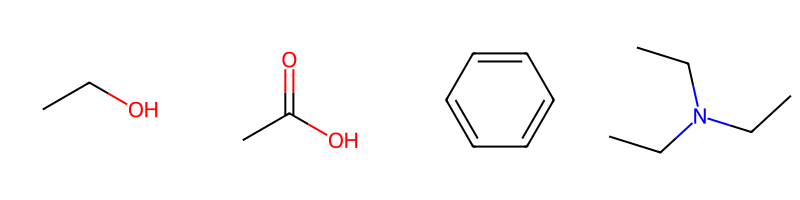

(3, 3)
(4, 4)
(6, 6)
(7, 7)


In [10]:
# Crea un grafo NetworkX dalla molecola
# === Step 2: RDKit allows to visualize the diagram/representation of the modleculase ===
img = Draw.MolsToGridImage(mol_list, molsPerRow=4, subImgSize=(200, 200))
display(img)

# compute adjacency matrix for the molecules
for mol in mol_list:
    print(rdmolops.GetAdjacencyMatrix(mol).shape)


def mol_to_nx(mol):

    """ From RDKit molecule object to Network x object """
    G = nx.Graph()
    for atom in mol.GetAtoms():
        G.add_node(atom.GetIdx(), 
                   atomic_num=atom.GetAtomicNum(), 
                   symbol=atom.GetSymbol())
    for bond in mol.GetBonds():
        print(bond, bond.GetBondType())
        G.add_edge(bond.GetBeginAtomIdx(),
                   bond.GetEndAtomIdx(),
                   bond_type=str(bond.GetBondType()))
    return G

def plot_graph(G, node_size, node_color, smiles):

    """ Plot molecular pure graph, highlight node and edge labels """
    
    # Disegna il grafo
    pos = nx.spring_layout(G, seed=42)  # layout automatico
    
    # Disegna nodi
    nx.draw_networkx_nodes(G, pos, node_size=node_size, node_color=node_color)
    
    # Disegna etichette degli atomi
    labels = nx.get_node_attributes(G, 'symbol')    # atom labels
    nx.draw_networkx_labels(G, pos, labels, font_size=12)
    
    # Disegna archi e tipo di legame come etichetta
    nx.draw_networkx_edges(G, pos, width=2)
    edge_labels = {(i, j): str(d["bond_type"]) for i, j, d in G.edges(data=True)}
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=10)

    plt.title(f"Graph of Molecule {smiles}")
    plt.axis('off')

CC(=O)O
<rdkit.Chem.rdchem.Bond object at 0x7fc510549240> SINGLE
<rdkit.Chem.rdchem.Bond object at 0x7fc542a06ce8> DOUBLE
<rdkit.Chem.rdchem.Bond object at 0x7fc510549240> SINGLE


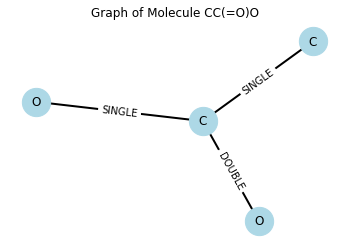

In [26]:
mol_idx = 1
print(smiles_list[mol_idx])
plot_graph(mol_to_nx(mol_list[mol_idx]), node_size = 800, node_color = 'lightblue', smiles = smiles_list[mol_idx])

### Featurize molecular grahs

In [27]:
def atom_features(atom):

    return torch.tensor([
        atom.GetAtomicNum(),
        atom.GetDegree(),
        atom.GetImplicitValence(),
        atom.GetFormalCharge(),
        int(atom.GetIsAromatic())], dtype=torch.float)

def bond_features(bond):
    bt = bond.GetBondType()
    return torch.tensor([int(bt == Chem.rdchem.BondType.SINGLE),
                    int(bt == Chem.rdchem.BondType.DOUBLE),
                    int(bt == Chem.rdchem.BondType.TRIPLE),
                    int(bt == Chem.rdchem.BondType.AROMATIC)], dtype=torch.float)

In [30]:
mol = mol_list[1]
print(smiles_list[1])

atom_feats = []
edge_index = []
edge_attr = []

for atom in mol.GetAtoms():
    A = atom_features(atom)
    atom_feats.append(atom_features(atom))
    print(A)

for bond in mol.GetBonds():
        i = bond.GetBeginAtomIdx()
        j = bond.GetEndAtomIdx()
        edge_index.append([i, j])
        edge_index.append([j, i])  # bidirezionale
        edge_attr.append(bond_features(bond))
        edge_attr.append(bond_features(bond)) # if bidirectional, we miss half the bonds if we don't include the flipped one

print(edge_index)
print(edge_attr)

# check technicalities
x = torch.stack(atom_feats)
edge_index = torch.tensor(edge_index, dtype=torch.long).T   # transpose
edge_attr = torch.stack(edge_attr)

print(x.shape)
print(x)

print('\n')

print(edge_index.shape)
print(edge_index)

print('\n')

print(edge_attr.shape)
print(edge_attr)

y = 0
y = torch.tensor([y], dtype=torch.float)
print(type(y), y.shape)
# these features I would stack in a pytorch tensors and those would be good to be compatible with PyTorch Geometric

CC(=O)O
tensor([6., 1., 3., 0., 0.])
tensor([6., 3., 0., 0., 0.])
tensor([8., 1., 0., 0., 0.])
tensor([8., 1., 1., 0., 0.])
[[0, 1], [1, 0], [1, 2], [2, 1], [1, 3], [3, 1]]
[tensor([1., 0., 0., 0.]), tensor([1., 0., 0., 0.]), tensor([0., 1., 0., 0.]), tensor([0., 1., 0., 0.]), tensor([1., 0., 0., 0.]), tensor([1., 0., 0., 0.])]
torch.Size([4, 5])
tensor([[6., 1., 3., 0., 0.],
        [6., 3., 0., 0., 0.],
        [8., 1., 0., 0., 0.],
        [8., 1., 1., 0., 0.]])


torch.Size([2, 6])
tensor([[0, 1, 1, 2, 1, 3],
        [1, 0, 2, 1, 3, 1]])


torch.Size([6, 4])
tensor([[1., 0., 0., 0.],
        [1., 0., 0., 0.],
        [0., 1., 0., 0.],
        [0., 1., 0., 0.],
        [1., 0., 0., 0.],
        [1., 0., 0., 0.]])
<class 'torch.Tensor'> torch.Size([1])


In [34]:
# === Step 7: Converti in oggetti PyTorch Geometric, need to install pyGeometric ===
def mol_to_pyg_data(mol, y=0):
    atom_feats = []
    edge_index = []
    edge_attr = []

    for atom in mol.GetAtoms():
        atom_feats.append(atom_features(atom))    # need an 'atom_features()' function, which extracts attributes using RDKIT

    for bond in mol.GetBonds():
        i = bond.GetBeginAtomIdx()
        j = bond.GetEndAtomIdx()
        edge_index.append((i, j))
        edge_index.append((j, i))  # bidirezionale
        edge_attr.append(bond_features(bond))     # need a 'bond_features' function, see avobe

    x = torch.stack(atom_feats)
    edge_index = torch.tensor(edge_index, dtype=torch.long).T
    edge_attr = torch.stack(edge_attr)

    y = torch.tensor([y], dtype=torch.float)

    return Data(x=x, edge_index=edge_index, edge_attr=edge_attr, y=y)

# === Step 8: Crea lista di grafi ===
dataset = [mol_to_pyg_data(mol, y=i) for i, mol in enumerate(mol_list)]

# === Step 9: Esplora un grafo ===
print(dataset[0])
print("Node features:\n", dataset[0].x)
print("Edge index:\n", dataset[0].edge_index)
print("Edge attributes:\n", dataset[0].edge_attr)

NameError: name 'Data' is not defined

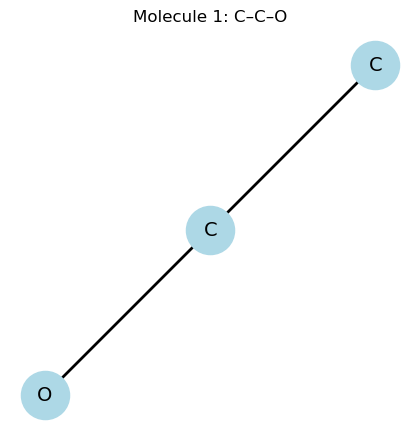

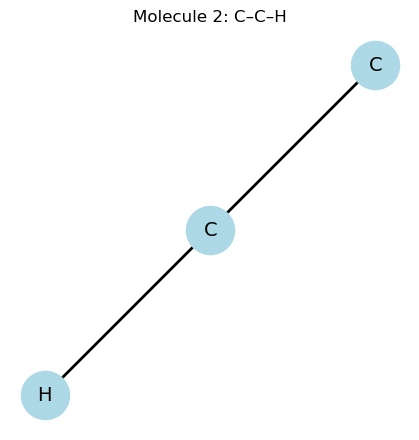

In [3]:
import networkx as nx
import matplotlib.pyplot as plt

def visualize_graph(edge_index, atom_types, title="Molecule"):
    G = nx.Graph()

    # Add nodes with atom labels
    for idx, atom in enumerate(atom_types):
        G.add_node(idx, label=atom)

    # Add edges
    for src, tgt in edge_index:
        G.add_edge(src, tgt)

    # Get labels
    labels = nx.get_node_attributes(G, 'label')
    
    # Layout
    pos = nx.spring_layout(G, seed=42)  # deterministic layout
    
    plt.figure(figsize=(4, 4))
    nx.draw(G, pos, with_labels=True, labels=labels, node_color='lightblue', node_size=1200, font_size=14)
    nx.draw_networkx_edges(G, pos, width=2)
    plt.title(title)
    plt.axis('off')
    plt.show()

# Visualize Molecule 1: C—C—O
mol1_atoms = ['C', 'C', 'O']
mol1_edges_list = [[0, 1], [1, 0], [1, 2], [2, 1]]
visualize_graph(mol1_edges_list, mol1_atoms, title="Molecule 1: C–C–O")

# Visualize Molecule 2: C—C—H
mol2_atoms = ['C', 'C', 'H']
mol2_edges_list = [[0, 1], [1, 0], [1, 2], [2, 1]]
visualize_graph(mol2_edges_list, mol2_atoms, title="Molecule 2: C–C–H")

### Hard-coded implementation of a GNN + classifier, using pytorch but NON pytorch.geometric

In [67]:
import torch
import torch.nn as nn
import torch.nn.functional as F   # these are the activation functions

# Set random seed for reproducibility
torch.manual_seed(42)

# === STEP 1: Hard-coded toy molecules: GRAPH FEATURIZATION ===

# Atom type to one-hot vector: C, O, H ... dictionary: the size of those vectors is a parameter to the model
atom_type_to_vec = {
    'C': [1, 0, 0, 0],
    'O': [0, 1, 0, 0],
    'H': [0, 0, 1, 0], 
    'S': [0, 0, 0, 1],
    'K': [2, 0, 0, 0]
}

# === Molecule 1: C—C—O (label 1: contains oxygen):

# node embeddings
mol1_nodes = torch.tensor([
    atom_type_to_vec['C'],
    atom_type_to_vec['C'],
    atom_type_to_vec['O']
], dtype=torch.float)

# edge embeddings (please note the symmetry)
mol1_edges = torch.tensor([
    [0, 1],  [1, 0],
    [1, 2],  [2, 1]
])

# === Molecule 2: C—C—H (label 0: no oxygen)
# node embeddings
mol2_nodes = torch.tensor([
    atom_type_to_vec['C'],
    atom_type_to_vec['C'],
    atom_type_to_vec['H']
], dtype=torch.float)

# edge embeddings
mol2_edges = torch.tensor([
    [0, 1],    [1, 0],
    [1, 2],    [2, 1]
])

assert mol2_nodes.shape[1] == 4   # are all nodes correctly embedded?

# this example only has nodes, node attributes and edges, no edge attribute.
# if we want to include the edge attributres, then we'd have to use another type of layer, not just the GNN

# Labels: 1 if contains oxygen, else 0, this is the trainign data
# LABELS ON TRAINING DATA
labels = torch.tensor([1, 0], dtype=torch.float)

### Define GNN layer

In [71]:
class GNNLayer(nn.Module):   #base class for all neural network components in pytorch
    
    def __init__(self, in_dim, out_dim):   # constructor
        super().__init__()
        self.linear = nn.Linear(in_dim, out_dim)      # The Linear layer is our learnable function that updates node embeddings after aggregating messages.
                                                      # e' la classica y = xW.T + b delle reti fully connected
    def forward(self, x, edge_index):   # this function MUST be overridded everytime
        """
        x: [num_nodes, in_dim]
        edge_index: [num_edges, 2], where each row is [source, target]

        This is the key method that does the **message passing** and **embedding update**.
        This details how data flows from one layer to the next
        """
        
        num_nodes = x.size(0)
        messages = torch.zeros(num_nodes, x.size(1))

        # message passing + basic aggregating (= sum!); just node embeddings
        for src, tgt in edge_index:
            messages[tgt] += x[src]  # Add message from src to tgt: messages[i] will hold the sum of all messages received by node i from its neighbors.

        """This is the UPDATE step:

        Each node has received messages from neighbors (i.e., messages[i]). 
        We transform those aggregated messages using a linear layer (i.e., a fully connected layer with weights and bias).
        This is a learnable transformation to produce updated node embeddings"""
        
        out = self.linear(messages)
        out = F.relu(out)    # increase expressivity, questo e' quello che c'e' nelle reti normali RElu(linear transfomration) to
                             # introduce non-linearity in the representation
        return out

""" Output is the updated node embeddings after this GNN layer. These can be fed to: another GNN layer, a pooling layer
(to get a graph embedding), a classifier or regressor"""

# === STEP 3: Define Graph-level GNN model ===

class GraphClassifier(nn.Module):

    """
    This defines a PyTorch model that:
    - Takes a molecular graph as input (nodes + edges)
    - Uses 2 GNN layers to update atom (node) embeddings
    - Pools those embeddings into a single graph embedding
    - Passes that through an MLP classifier
    - Returns a **binary classification prediction** (between 0 and 1)
    """
    
    def __init__(self, in_dim, hidden_dim):
        super().__init__()
        self.gnn1 = GNNLayer(in_dim, hidden_dim)  # MESSAGE PASSING + NON-LINEAR LEARNABLE FUNCTION 
                                                        # here we are modulating the dimension of the embeddings
        self.gnn2 = GNNLayer(hidden_dim, hidden_dim)   # MESSAGE PASSING + NON-LINEAR LEARNABLE FUNCTION
        
        # we a re not changing the graph connectivity or number of nodes BY ANY MEANS
        self.classifier = nn.Linear(hidden_dim, 1)   # takes graph level embedding and maps it to a logit only
                                                     # which will then be sqashed to 1 or 0 by a sigmoid (classification)

    def forward(self, node_feats, edge_index):   # define the architecture
        h = self.gnn1(node_feats, edge_index)
        h = self.gnn2(h, edge_index)

        # Sum pooling: [num_nodes, hidden_dim] → [1, hidden_dim], from node to graph embedding
        graph_embedding = h.sum(dim=0, keepdim=True)          # final pooling: collect all nodes into a graph thing 
                                                            # a node classifier would not have this
        """In GNNs, after several message-passing layers, each node has its own learned embedding vector 
                                                            — a dense feature representation summarizing its local neighborhood. But often, you want a single 
                                                            vector representing the entire graph (e.g., a molecule) for tasks like classification or regression."""
        out = self.classifier(graph_embedding)  # [1, 1]
        return torch.sigmoid(out).squeeze()     # Scalar between 0 and 1, to classify




### === STEP 4: Instantiate model and optimizer, and train ===

In [72]:

model = GraphClassifier(in_dim=4, hidden_dim=8)    # each node comes with a [x,y,z, t] 3D embedding
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)   # optimizer
loss_fn = nn.BCELoss()      # binary cross entropy

print(model)
# === STEP 5: Training loop ===

for epoch in range(100):
    model.train()
    optimizer.zero_grad()    ### initialize the gradients for backpropagation

    pred1 = model(mol1_nodes, mol1_edges)    # run this on molecule 1
    pred2 = model(mol2_nodes, mol2_edges)    # tun this on molecule 2
    
    print(pred1, pred2)   # each prediction is a 1x1 pytorch tensor with the probability

    preds = torch.stack([pred1, pred2])
    loss = loss_fn(preds, labels)          # preds are from the input, labels are the known labels

    loss.backward()
    optimizer.step()

    if epoch % 10 == 0 or epoch == 99:
        with torch.no_grad():
            pred_class = (preds > 0.5).int()
            acc = (pred_class == labels.int()).float().mean()
            print(f"Epoch {epoch:3d} | Loss: {loss.item():.4f} | Accuracy: {acc:.2f}")

# the model GraphClassifier is now optimized


GraphClassifier(
  (gnn1): GNNLayer(
    (linear): Linear(in_features=4, out_features=8, bias=True)
  )
  (gnn2): GNNLayer(
    (linear): Linear(in_features=8, out_features=8, bias=True)
  )
  (classifier): Linear(in_features=8, out_features=1, bias=True)
)
tensor(0.6587, grad_fn=<SqueezeBackward0>) tensor(0.6135, grad_fn=<SqueezeBackward0>)
Epoch   0 | Loss: 0.6840 | Accuracy: 0.50
tensor(0.6306, grad_fn=<SqueezeBackward0>) tensor(0.5700, grad_fn=<SqueezeBackward0>)
tensor(0.6049, grad_fn=<SqueezeBackward0>) tensor(0.5295, grad_fn=<SqueezeBackward0>)
tensor(0.5821, grad_fn=<SqueezeBackward0>) tensor(0.4918, grad_fn=<SqueezeBackward0>)
tensor(0.5635, grad_fn=<SqueezeBackward0>) tensor(0.4631, grad_fn=<SqueezeBackward0>)
tensor(0.5511, grad_fn=<SqueezeBackward0>) tensor(0.4417, grad_fn=<SqueezeBackward0>)
tensor(0.5440, grad_fn=<SqueezeBackward0>) tensor(0.4228, grad_fn=<SqueezeBackward0>)
tensor(0.5416, grad_fn=<SqueezeBackward0>) tensor(0.4065, grad_fn=<SqueezeBackward0>)
tensor(0.543

Epoch  99 | Loss: 0.0024 | Accuracy: 1.00


### == STEP 5: predictions ===

In [63]:
# === STEP 6: Final predictions ===

with torch.no_grad():     # Useful during inference, evaluation, or any time you don’t need to update model parameters.
                          # predictions and assessments do not require storing gradient information
    print("\nFinal predictions:")
    print(f"Molecule 1 (C-C-O): {model(mol1_nodes, mol1_edges).item():.3f}")
    print(f"Molecule 2 (C-C-H): {model(mol2_nodes, mol2_edges).item():.3f}")

    
# idea: use a dictionary to loop over the different input moleuclar graphs to be processed


Final predictions:
Molecule 1 (C-C-O): 0.999
Molecule 2 (C-C-H): 0.001


### === STEP 6: prediction into a new molecule ====

In [64]:
mol3_nodes = torch.tensor([
    atom_type_to_vec['S'],
    atom_type_to_vec['C'],
    atom_type_to_vec['H']
], dtype=torch.float)

mol3_edges = torch.tensor([
    [0, 1],
    [1, 0],
    [1, 2],
    [2, 1],
    [0, 2],
    [2, 0]
])

print(mol3_nodes.shape)
print(mol3_edges.shape)

torch.Size([3, 4])
torch.Size([6, 2])


In [65]:
model(mol2_nodes, mol2_edges)

tensor(0.0005, grad_fn=<SqueezeBackward0>)